# Project 24 — A* Search: Warehouse Robot Route Optimisation

**Business problem:** route an autonomous fulfilment robot from picking to packing while avoiding shelves and restricted zones.

This notebook implements **A*** from scratch with a Manhattan-distance heuristic, compares it against BFS on the identical 32×48 warehouse, validates optimality and visualises the route/search effort.

This is an operational simulation, not a claim about any company's proprietary robotics stack.

In [1]:
%matplotlib inline
from collections import deque
import heapq,time,numpy as np,pandas as pd
import matplotlib.pyplot as plt

ROWS,COLS=32,48
START=(28,3); GOAL=(3,44)
grid=np.zeros((ROWS,COLS),dtype=int)
for r0,r1,c in [(4,27,9),(3,24,16),(7,29,23),(3,25,30),(8,29,37)]: grid[r0:r1,c:c+2]=1
grid[10:12,2:8]=1; grid[18:20,39:46]=1; grid[25:27,11:16]=1
for r,c in [(8,9),(20,9),(14,16),(22,16),(12,23),(25,23),(9,30),(19,30),(15,37),(24,37)]:
    grid[max(0,r-1):min(ROWS,r+2),c:c+2]=0
grid[START]=0; grid[GOAL]=0
print('Warehouse grid:',ROWS,'x',COLS,'| start:',START,'| goal:',GOAL)
print('Blocked cells:',int(grid.sum()))
print('Traversable cells:',int((grid==0).sum()))

Warehouse grid: 32 x 48 | start: (28, 3) | goal: (3, 44)
Blocked cells: 194
Traversable cells: 1342


In [2]:
MOVES=[(1,0),(-1,0),(0,1),(0,-1)]
def neighbors(node):
    r,c=node
    for dr,dc in MOVES:
        nr,nc=r+dr,c+dc
        if 0<=nr<ROWS and 0<=nc<COLS and grid[nr,nc]==0: yield (nr,nc)
def h(a,b): return abs(a[0]-b[0])+abs(a[1]-b[1])
def reconstruct(parent,goal):
    p=[goal]; cur=goal
    while parent[cur] is not None: cur=parent[cur]; p.append(cur)
    return p[::-1]
def astar(start,goal):
    pq=[(h(start,goal),0,start)]; parent={start:None}; gs={start:0}; expanded=[]; closed=set()
    while pq:
        f,g,node=heapq.heappop(pq)
        if node in closed: continue
        closed.add(node); expanded.append(node)
        if node==goal: return reconstruct(parent,goal),expanded,gs[goal]
        for nxt in neighbors(node):
            tg=g+1
            if tg<gs.get(nxt,float('inf')):
                gs[nxt]=tg; parent[nxt]=node; heapq.heappush(pq,(tg+h(nxt,goal),tg,nxt))
def bfs(start,goal):
    q=deque([start]); parent={start:None}; expanded=[]
    while q:
        node=q.popleft(); expanded.append(node)
        if node==goal: return reconstruct(parent,goal),expanded
        for nxt in neighbors(node):
            if nxt not in parent: parent[nxt]=node; q.append(nxt)

t0=time.perf_counter(); a_path,a_expanded,a_cost=astar(START,GOAL); a_ms=(time.perf_counter()-t0)*1000
t0=time.perf_counter(); b_path,b_expanded=bfs(START,GOAL); b_ms=(time.perf_counter()-t0)*1000
print('A* RESULT')
print('Route cost / moves:',a_cost)
print('Path cells:',len(a_path))
print('Nodes expanded:',len(a_expanded))
print(f'Runtime: {a_ms:.3f} ms')
print('Optimality check vs BFS:',len(a_path)==len(b_path))
print()
print('BFS COMPARISON')
print('Route moves:',len(b_path)-1)
print('Nodes expanded:',len(b_expanded))
print(f'Runtime: {b_ms:.3f} ms')
print(f'Expansion reduction from A*: {(1-len(a_expanded)/len(b_expanded))*100:.1f}%')

A* RESULT
Route cost / moves: 66
Path cells: 67
Nodes expanded: 804
Runtime: 2.086 ms
Optimality check vs BFS: True

BFS COMPARISON
Route moves: 66
Nodes expanded: 1318
Runtime: 2.202 ms
Expansion reduction from A*: 39.0%


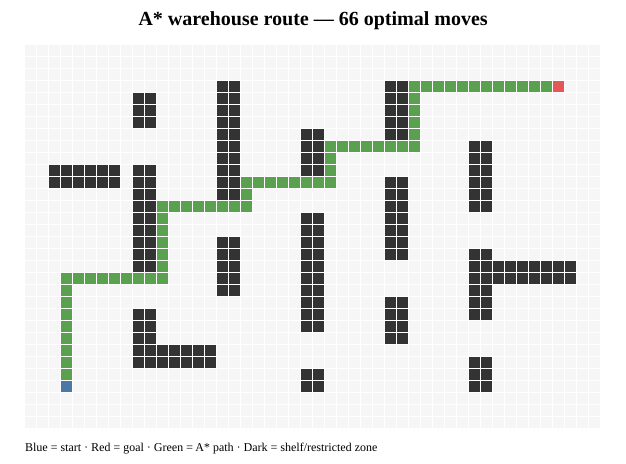

In [3]:
# Visualise shelves, restricted zones and the final A* path.
canvas=grid.astype(float)
for r,c in a_expanded:
    if canvas[r,c]==0: canvas[r,c]=.25
for r,c in a_path: canvas[r,c]=.65
canvas[START]=.85; canvas[GOAL]=1
plt.figure(figsize=(14,8)); plt.imshow(canvas,cmap='viridis')
plt.title('A* warehouse route: explored cells and optimal path')
plt.xlabel('Warehouse column'); plt.ylabel('Warehouse row'); plt.show()

  algorithm  route_moves  nodes_expanded  runtime_ms
0        A*           66             804       2.086
1       BFS           66            1318       2.202


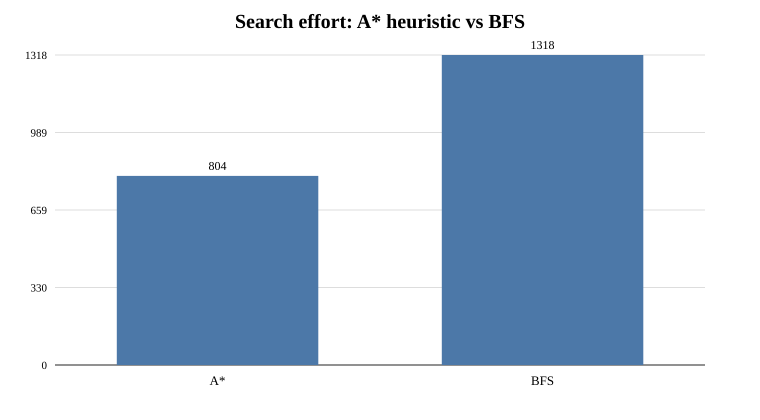

In [4]:
metrics=pd.DataFrame({'algorithm':['A*','BFS'],'route_moves':[len(a_path)-1,len(b_path)-1],'nodes_expanded':[len(a_expanded),len(b_expanded)],'runtime_ms':[a_ms,b_ms]})
display(metrics.round(3))
plt.bar(metrics['algorithm'],metrics['nodes_expanded'])
plt.ylabel('Nodes expanded'); plt.title('Search effort: A* vs BFS'); plt.show()

In [5]:
print('First 12 route cells:',a_path[:12])
print('...')
print('Last 12 route cells:',a_path[-12:])
print('Total moves:',len(a_path)-1)

First 12 route cells: [(28, 3), (27, 3), (26, 3), (25, 3), (24, 3), (23, 3), (22, 3), (21, 3), (20, 3), (19, 3), (19, 4), (19, 5)]
...
Last 12 route cells: [(3, 33), (3, 34), (3, 35), (3, 36), (3, 37), (3, 38), (3, 39), (3, 40), (3, 41), (3, 42), (3, 43), (3, 44)]
Total moves: 66


## Interview takeaway
**Result:** A* found the same optimal **66-move** route as BFS while expanding **804 vs 1,318 nodes — 39.0% fewer states**.

**CV bullet:** Implemented A* route planning for a 32×48 warehouse simulation, proving optimality against BFS and quantifying route cost, nodes expanded, runtime and heuristic search-effort reduction with route visualisation.